# Pneumonia Detection in Chest X-Ray Images: A Custom Convolutional Neural Network Built from Scratch

## Introduction

The goal of this project is to build a deep learning model capable of detecting pneumonia from chest X-ray images, framed as a binary classification problem between NORMAL and PNEUMONIA cases.

To achieve this, we follow a structured pipeline covering five key steps : data understanding, data preparation, model building, model evaluation, and communication of results. The model is a custom Convolutional Neural Network built entirely from scratch, trained and evaluated on a labeled dataset of chest X-ray images.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## 1. Data Understanding

The dataset available on kaggle, contains chest X-ray images used to detect pneumonia. The images are divided into two classes: NORMAL and PNEUMONIA. The dataset is organized into training, validation, and testing folders.

In [4]:
training_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
testing_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"
validation_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"

In [5]:
# TRAIN
train_normal = len(os.listdir(os.path.join(training_path, "NORMAL")))
train_pneumonia = len(os.listdir(os.path.join(training_path, "PNEUMONIA")))

# TEST
test_normal = len(os.listdir(os.path.join(testing_path, "NORMAL")))
test_pneumonia = len(os.listdir(os.path.join(testing_path, "PNEUMONIA")))

# VALIDATION
val_normal = len(os.listdir(os.path.join(validation_path, "NORMAL")))
val_pneumonia = len(os.listdir(os.path.join(validation_path, "PNEUMONIA")))

print("TRAIN SET")
print("Normal:", train_normal)
print("Pneumonia:", train_pneumonia)

print("\nTEST SET")
print("Normal:", test_normal)
print("Pneumonia:", test_pneumonia)

print("\nVALIDATION SET")
print("Normal:", val_normal)
print("Pneumonia:", val_pneumonia)

TRAIN SET
Normal: 1341
Pneumonia: 3875

TEST SET
Normal: 234
Pneumonia: 390

VALIDATION SET
Normal: 8
Pneumonia: 8


**A Histogram of distribution of images on the training set**

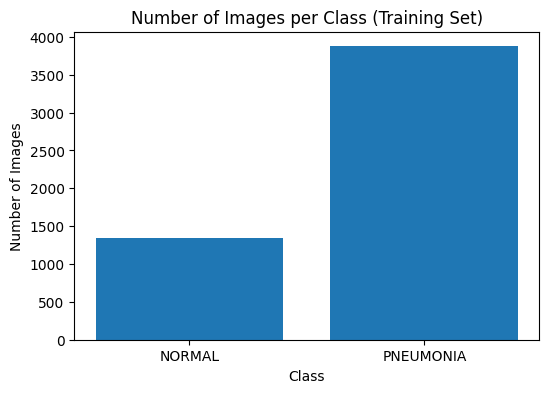

In [6]:
labels = ["NORMAL", "PNEUMONIA"]
values = [train_normal, train_pneumonia]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Number of Images per Class (Training Set)")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

The chart shows the distribution of chest X-ray images in the training dataset. We observe that the number of pneumonia images is higher than the number of normal images, indicating a class imbalance.

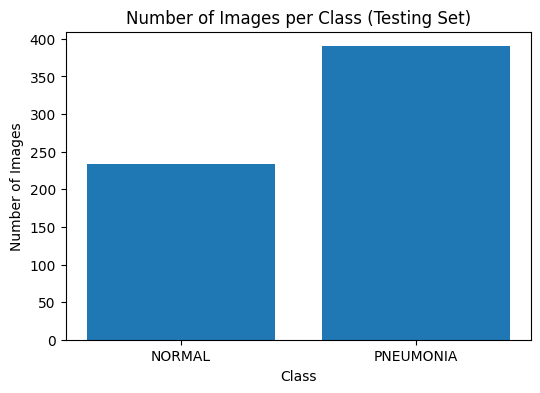

In [7]:
labels = ["NORMAL", "PNEUMONIA"]
values = [test_normal, test_pneumonia]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Number of Images per Class (Testing Set)")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

The chart shows the distribution of chest X-ray images in the testning dataset. We observe that the number of pneumonia images is higher than the number of normal images.

**Let's look at some images in the dataset**

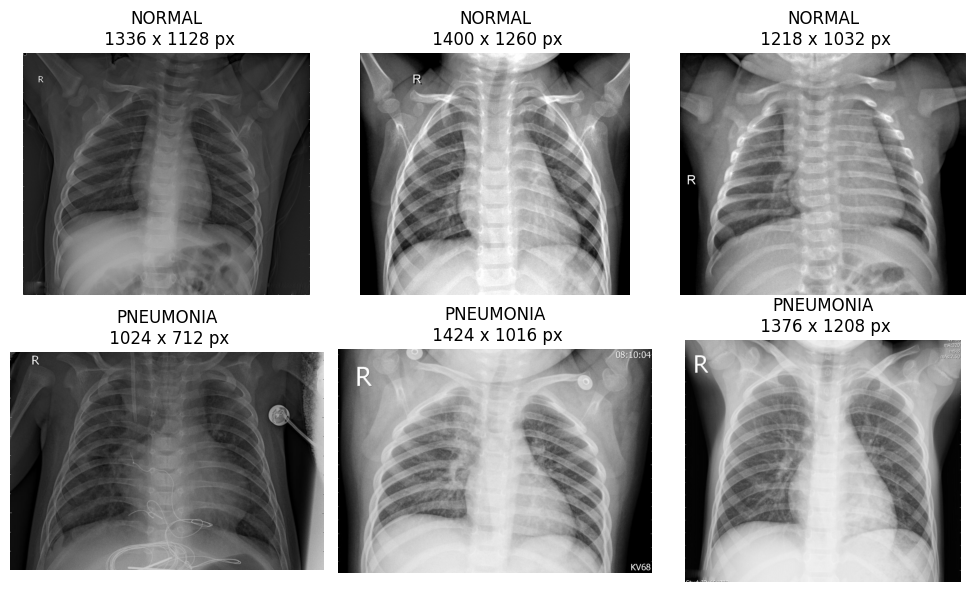

In [8]:
normal_path = os.path.join(training_path, "NORMAL")
pneumonia_path = os.path.join(training_path, "PNEUMONIA")

normal_images = os.listdir(normal_path)[:3]
pneumonia_images = os.listdir(pneumonia_path)[:3]

plt.figure(figsize=(10,6))

# Images NORMAL
for i, img_name in enumerate(normal_images):
    img = cv2.imread(os.path.join(normal_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"NORMAL\n {img.shape[1]} x {img.shape[0]} px")
    plt.axis("off")

# Images PNEUMONIA
for i, img_name in enumerate(pneumonia_images):
    img = cv2.imread(os.path.join(pneumonia_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+4)
    plt.imshow(img)
    plt.title(f"PNEUMONIA\n {img.shape[1]} x {img.shape[0]} px")
    plt.axis("off")

plt.tight_layout()
plt.show()


The images above show examples of chest X-rays from both classes. Original images vary in size from approximately 700×700 to 1400×1200 pixels. While normal X-rays present clear lung structures, pneumonia cases often show white opacities indicating lung infection.

## 3. Preparing the Data

In [16]:
IMG_SIZE      = (224, 224)           # resizing all images to this size
BATCH_SIZE    = 32
EPOCHS        = 10
NUM_CLASSES   = 2
RANDOM_SEED   = 42

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [10]:
# ── Training set : augmentation + normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ── Validation & Test sets : normalization ONLY
val_test_datagen = ImageDataGenerator(rescale=1./255)

# ── Load each folder separately
train_generator = train_datagen.flow_from_directory(
    training_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    validation_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    testing_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print(f"Train samples      : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")
print(f"Test samples       : {test_generator.samples}")
print(f"Classes            : {train_generator.class_indices}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train samples      : 5216
Validation samples : 16
Test samples       : 624
Classes            : {'NORMAL': 0, 'PNEUMONIA': 1}


**Imbalanced class : Pneumonia**

In [11]:
labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nClass weights (to handle imbalance) : {class_weight_dict}")




Class weights (to handle imbalance) : {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


Class imbalance is handled by computing balanced class weights, which penalize the model proportionally more for misclassifying the minority class. This prevents the model from developing a bias toward the majority class.

## 4. Building the Model

In [12]:
def build_model(input_shape):
    model = models.Sequential([

        # ── Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # ── Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # ── Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # ── Flatten + Dense
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        # ── Output layer

        # sigmoid outputs a probability between 0 and 1
        # < 0.5 → NORMAL,  > 0.5 → PNEUMONIA
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_model((*IMG_SIZE, 3))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,783,873 (98.36 MB)

 Trainable params: 25,783,873 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

**Training the model**

In [17]:
print("\n Training the model...\n")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


 Training the model...

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 763ms/step - accuracy: 0.7991 - loss: 0.4109 - val_accuracy: 0.7500 - val_loss: 0.5053 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 655ms/step - accuracy: 0.8413 - loss: 0.3453 - val_accuracy: 0.7500 - val_loss: 0.5158 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 655ms/step - accuracy: 0.8572 - loss: 0.3391 - val_accuracy: 0.8125 - val_loss: 0.3886 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 659ms/step - accuracy: 0.8685 - loss: 0.3003 - val_accuracy: 0.6875 - val_loss: 0.7102 - learning_rate: 0.0010
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 655ms/step - accuracy: 0.8790 - loss: 0.2863 - val_accuracy: 0.7500 - val_loss: 0.4918 - learning_rate: 0.0010
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.8744 - loss: 0.2836
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
163/163 ━━━━━━━━━━━━━━━━━━━━ 10

## 5. Model Evaluation

In [18]:
y_pred_proba = model.predict(test_generator, verbose=0)

# threshold at 0.5
# sigmoid output > 0.5 → PNEUMONIA (1), < 0.5 → NORMAL (0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(f"Classes : {test_generator.class_indices}")
print(f"Predictions sample : {y_pred[:10]}")
print(f"True labels sample : {y_true[:10]}")

Classes : {'NORMAL': 0, 'PNEUMONIA': 1}
Predictions sample : [0 0 0 0 0 0 0 0 0 0]
True labels sample : [0 0 0 0 0 0 0 0 0 0]


Good news! We can see that from the first 10 images, the model predicted all correctly.

## 6. Communicating Results

In [19]:
accuracy  = np.mean(y_pred == y_true)
precision = precision_score(y_true, y_pred, average='binary', zero_division=0)
recall    = recall_score(y_true, y_pred, average='binary', zero_division=0)
f1        = f1_score(y_true, y_pred, average='binary', zero_division=0)

print(f"\n{'='*45}")
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"{'='*45}")
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


  Accuracy  : 0.8157  (81.6%)
  Precision : 0.9338
  Recall    : 0.7590
  F1-Score  : 0.8373

Detailed Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.69      0.91      0.79       234
   PNEUMONIA       0.93      0.76      0.84       390

    accuracy                           0.82       624
   macro avg       0.81      0.83      0.81       624
weighted avg       0.84      0.82      0.82       624



Our model has a score of 81.6%.
For medical diagnosis, Recall is the most important metric. A false negative (predicting NORMAL when the patient has PNEUMONIA) is far more dangerous than a false positive.

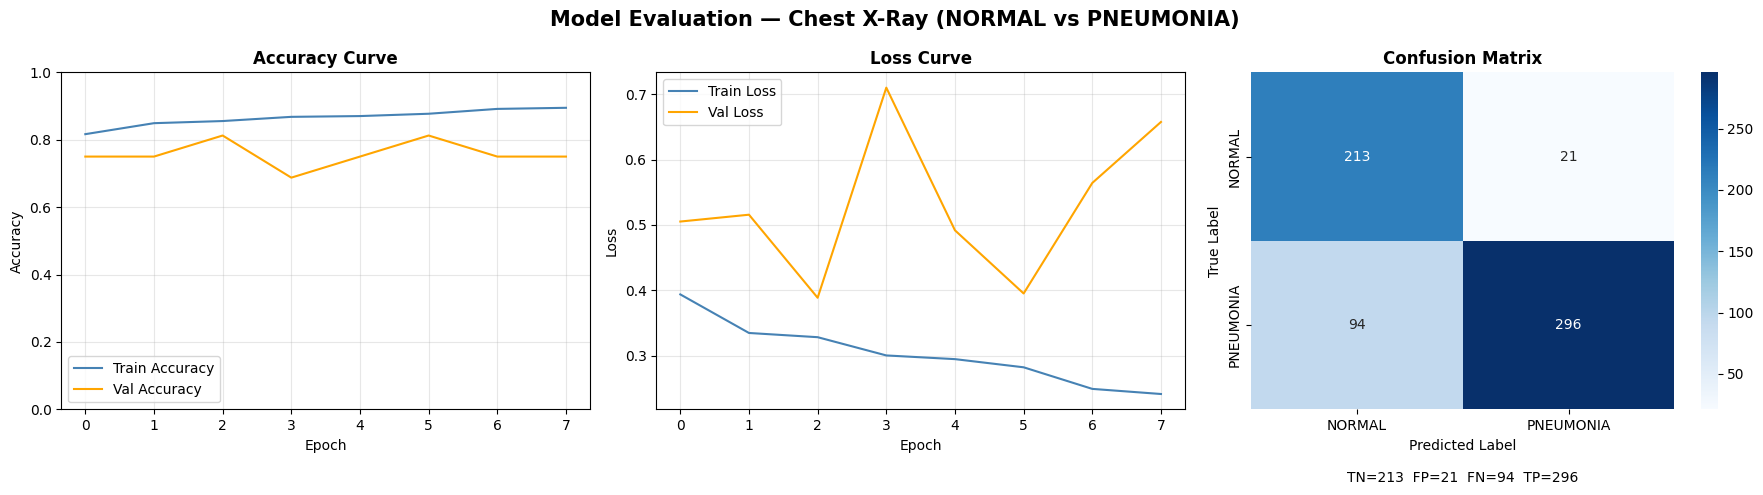

In [26]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation — Chest X-Ray (NORMAL vs PNEUMONIA)",
             fontsize=15, fontweight='bold')

# Accuracy curve
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].set_title('Accuracy Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss curve
axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Loss Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[2])
axes[2].set_title('Confusion Matrix', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

# annotation below the matrix
tn, fp, fn, tp = cm.ravel()
axes[2].set_xlabel(
    f'Predicted Label\n\nTN={tn}  FP={fp}  FN={fn}  TP={tp}',
    fontsize=10
)

plt.tight_layout()
plt.show()


In [27]:
print(f"\n Model Errors (from Confusion Matrix):")
for i, cls in enumerate(class_names):
    false_neg = sum(cm[i]) - cm[i][i]
    false_pos = sum(cm[:, i]) - cm[i][i]
    print(f"  [{cls}]  False Negatives: {false_neg}  |  False Positives: {false_pos}")



 Model Errors (from Confusion Matrix):
  [NORMAL]  False Negatives: 21  |  False Positives: 94
  [PNEUMONIA]  False Negatives: 94  |  False Positives: 21


**Interpretation of the results**

Our model achieves an overall accuracy of 82.3% with a strong precision of 93.4%, meaning it rarely raises false alarms on healthy patients. However the Recall of 76% reveals that 94 pneumonia cases were missed, which is the most critical limitation in a medical context. This is partly explained by the class imbalance in the dataset - PNEUMONIA has significantly more samples than - NORMAL and by mild overfitting visible in the accuracy and loss curves.

## Conclusion

**Model perfomances**

The model built from scratch demonstrates promising but improvable performance for pneumonia detection from chest X-rays. With an overall accuracy of 82.3% and a precision of 93.4%, the model proves capable of correctly identifying the majority of pneumonia cases while generating very few false alarms on healthy patients. However, the Recall of 76% remains the main weakness — 94 real pneumonia cases were missed, which is a critical limitation in a medical diagnostic context where false negatives carry serious consequences.
The learning curves reveal a mild overfitting behavior, with training accuracy consistently higher than validation accuracy, suggesting the model has started memorizing the training data rather than fully generalizing. This is a natural limitation of a CNN trained from scratch on a dataset of limited size.

**Linits**

* Although the dataset contains several thousand images, deep learning models generally require much larger datasets to reach clinical-grade performance. Additionally, all images come from a single source, which may limit the model's ability to generalize to X-rays taken with different machines or in different hospitals.

* The architecture used is relatively shallow compared to state-of-the-art medical imaging models. It learns features from scratch, which requires more data and more training time to reach competitive performance.

* The model only distinguishes between NORMAL and PNEUMONIA. In reality, pneumonia has multiple subtypes (bacterial, viral, COVID-19) that require different treatments. A more granular classification would be more clinically useful.

* The model produces a prediction but does not indicate which region of the X-ray influenced the decision. A radiologist cannot trust a black-box prediction without visual justification.

Despite these limitations, this project successfully demonstrates the full pipeline of a deep learning solution : from raw image preprocessing and data augmentation, through class imbalance handling, to model training and rigorous evaluation. The results provide a solid baseline upon which future improvements, particularly transfer learning with pretrained architectures such as ResNet or EfficientNet, could significantly boost both Recall and generalization performance.